# Healthy vs Disease Classification from Bacterial Composition

## Publication-oriented, participant-level pipeline

**Objective**

- Input: participant-level bacterial composition
- Output:
  - `0 = Healthy`
  - `1 = Disease` (Crohn's disease or ulcerative colitis)

This notebook is designed to avoid optimistic leakage and disease-biased predictions.

### Main safeguards and improvements

1. Multiple samples from the same participant are aggregated before modelling.
2. A stratified participant-level test set is held out and untouched during model/threshold selection.
3. Prevalence filtering, CLR transformation and feature selection occur inside pipelines.
4. Boruta-style shadow-feature selection is used for robust taxa selection.
5. Logistic regression, Random Forest, Extra Trees, HistGradientBoosting and optional XGBoost/LightGBM/CatBoost are compared.
6. Nested cross-validation is used for model and hyperparameter selection.
7. Probabilities are calibrated.
8. The classification threshold is selected only from out-of-fold training predictions.
9. The threshold objective explicitly balances Healthy recall and Disease recall.
10. Bootstrap confidence intervals and feature interpretation are reported.

> No machine-learning pipeline can guarantee high clinical accuracy. The notebook reports honest held-out performance and confidence intervals.

In [ ]:
# Optional installs for Colab.
# Uncomment only when the corresponding package is unavailable.
!pip -q install xgboost lightgbm catboost shap

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import math
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
OUTER_SPLITS = 5
INNER_SPLITS = 4

# FAST_MODE=True gives a practical Colab runtime.
# Set False for a larger publication run.
FAST_MODE = True
SEARCH_ITER = 10 if FAST_MODE else 35
N_JOBS = -1

# Threshold selection constraints.
MIN_HEALTHY_RECALL = 0.60
MIN_DISEASE_RECALL = 0.60

DATA_CANDIDATES = [
    Path("/content/hmp2_ibd_metagenomics_atlas_20260219_121629.csv"),

]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Upload the CSV to Colab or update DATA_CANDIDATES with its path."
    )

print("Dataset:", DATA_PATH)
print("FAST_MODE:", FAST_MODE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00
Dataset: /content/hmp2_ibd_metagenomics_atlas_20260219_121629.csv
FAST_MODE: True


In [ ]:
# Load and validate data
raw = pd.read_csv(DATA_PATH)

required = {"Participant ID", "diagnosis"}
missing = required.difference(raw.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

LABEL_MAP = {
    "Healthy": 0,
    "Crohns Disease": 1,
    "Crohn's Disease": 1,
    "Ulcerative Colitis": 1,
}

raw["target"] = raw["diagnosis"].map(LABEL_MAP)
unknown = raw.loc[raw["target"].isna(), "diagnosis"].dropna().unique()
if len(unknown):
    print("Excluded unmapped diagnoses:", unknown.tolist())

raw = raw.dropna(subset=["Participant ID", "target"]).copy()
raw["target"] = raw["target"].astype(int)

metadata_cols = {
    "External ID", "Participant ID", "week_num",
    "diagnosis", "fecalcal", "target"
}
taxa_cols = [
    c for c in raw.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(raw[c])
]

if not taxa_cols:
    raise ValueError("No numeric bacterial composition columns were detected.")

raw[taxa_cols] = (
    raw[taxa_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .clip(lower=0.0)
)

print("Samples:", len(raw))
print("Participants:", raw["Participant ID"].nunique())
print("Taxa features:", len(taxa_cols))
print("\nParticipant diagnosis counts:")
display(
    raw.groupby("Participant ID")["target"].first()
       .value_counts().rename(index={0: "Healthy", 1: "Disease"})
)

Samples: 3387
Participants: 116
Taxa features: 566

Participant diagnosis counts:


,count
target,
Disease,89
Healthy,27


In [ ]:
# Verify that every participant has one consistent binary label.
label_counts = raw.groupby("Participant ID")["target"].nunique()
inconsistent = label_counts[label_counts > 1]

if len(inconsistent):
    raise ValueError(
        f"{len(inconsistent)} participants have inconsistent labels. "
        "Resolve them before modelling."
    )

# Aggregate repeated samples per participant using the median.
# Median is less sensitive than the mean to episodic abundance spikes.
participant_taxa = raw.groupby("Participant ID")[taxa_cols].median()
participant_target = raw.groupby("Participant ID")["target"].first()

# Ecological summary features calculated before CLR.
presence = participant_taxa.gt(0)
richness = presence.sum(axis=1).astype(float)

relative = participant_taxa.div(
    participant_taxa.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)

shannon = -(relative.where(relative > 0) * np.log(relative.where(relative > 0))).sum(axis=1)
simpson = 1.0 - (relative ** 2).sum(axis=1)
dominance = relative.max(axis=1)
evenness = shannon / np.log(richness.clip(lower=2))

ecology = pd.DataFrame({
    "ecology_species_richness": richness,
    "ecology_shannon": shannon.fillna(0),
    "ecology_simpson": simpson.fillna(0),
    "ecology_dominance": dominance.fillna(0),
    "ecology_evenness": evenness.replace([np.inf, -np.inf], np.nan).fillna(0),
})

X_all = pd.concat([participant_taxa, ecology], axis=1)
y_all = participant_target.loc[X_all.index]

print("Participant-level feature matrix:", X_all.shape)
display(
    y_all.value_counts()
         .rename(index={0: "Healthy", 1: "Disease"})
         .to_frame("participants")
)

Participant-level feature matrix: (116, 571)


,participants
target,
Disease,89
Healthy,27


In [ ]:
# Fixed participant-level hold-out test set.
# It is not used during model comparison, tuning, calibration or threshold selection.
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

print("Training participants:", len(X_train))
print(y_train.value_counts().rename(index={0: "Healthy", 1: "Disease"}))
print("\nHeld-out test participants:", len(X_test))
print(y_test.value_counts().rename(index={0: "Healthy", 1: "Disease"}))

assert set(X_train.index).isdisjoint(set(X_test.index))

Training participants: 92
target
Disease    71
Healthy    21
Name: count, dtype: int64

Held-out test participants: 24
target
Disease    18
Healthy     6
Name: count, dtype: int64


In [ ]:
class PrevalenceFilter(BaseEstimator, TransformerMixin):
    """Keep features present above a minimum fraction of training rows."""

    def __init__(self, min_prevalence=0.10, ecology_prefix="ecology_"):
        self.min_prevalence = min_prevalence
        self.ecology_prefix = ecology_prefix

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        ecology_mask = X.columns.astype(str).str.startswith(self.ecology_prefix)
        prevalence = (X > 0).mean(axis=0)
        self.support_ = (prevalence >= self.min_prevalence).to_numpy() | ecology_mask
        if not np.any(self.support_):
            raise ValueError("PrevalenceFilter removed every feature.")
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        return X.loc[:, self.support_]

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_[self.support_]


class CLRTransformer(BaseEstimator, TransformerMixin):
    """CLR-transform taxa; standardise ecological columns later in the pipeline."""

    def __init__(self, pseudocount=1e-6, ecology_prefix="ecology_"):
        self.pseudocount = pseudocount
        self.ecology_prefix = ecology_prefix

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.ecology_mask_ = np.array([
            str(c).startswith(self.ecology_prefix) for c in self.feature_names_in_
        ])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).astype(float)
        out = X.copy()
        taxa_mask = ~self.ecology_mask_

        taxa = X.loc[:, taxa_mask].clip(lower=0.0) + self.pseudocount
        log_taxa = np.log(taxa)
        out.loc[:, taxa_mask] = log_taxa.sub(log_taxa.mean(axis=1), axis=0)

        return out.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_


class BorutaShadowSelector(BaseEstimator, TransformerMixin):
    """
    Lightweight Boruta-style selector.

    For each repeat, shuffled shadow features are appended. A real feature is
    counted as a hit when its RF importance exceeds a chosen shadow quantile.
    Features reaching min_hit_rate are kept. A minimum number is retained to
    prevent unstable empty/small sets.
    """

    def __init__(
        self,
        n_estimators=300,
        max_depth=7,
        n_repeats=5,
        shadow_quantile=95,
        min_hit_rate=0.60,
        min_features=20,
        max_features=250,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.n_repeats = n_repeats
        self.shadow_quantile = shadow_quantile
        self.min_hit_rate = min_hit_rate
        self.min_features = min_features
        self.max_features = max_features
        self.class_weight = class_weight
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        hits = np.zeros(n_features, dtype=float)
        mean_importance = np.zeros(n_features, dtype=float)

        for repeat in range(self.n_repeats):
            shadow = np.empty_like(X)
            for j in range(n_features):
                shadow[:, j] = rng.permutation(X[:, j])

            augmented = np.hstack([X, shadow])
            forest = RandomForestClassifier(
                n_estimators=self.n_estimators,
                max_depth=self.max_depth,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight=self.class_weight,
                random_state=self.random_state + repeat,
                n_jobs=self.n_jobs,
            )
            forest.fit(augmented, y)
            real_imp = forest.feature_importances_[:n_features]
            shadow_imp = forest.feature_importances_[n_features:]
            threshold = np.percentile(shadow_imp, self.shadow_quantile)

            hits += real_imp > threshold
            mean_importance += real_imp

        self.hit_rate_ = hits / self.n_repeats
        self.mean_importance_ = mean_importance / self.n_repeats

        support = self.hit_rate_ >= self.min_hit_rate
        ranked = np.argsort(self.mean_importance_)[::-1]

        min_keep = min(self.min_features, n_features)
        if support.sum() < min_keep:
            support[ranked[:min_keep]] = True

        if self.max_features is not None and support.sum() > self.max_features:
            keep = ranked[:self.max_features]
            support[:] = False
            support[keep] = True

        self.support_ = support
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.support_]

    def get_support(self):
        return self.support_

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = np.arange(len(self.support_)).astype(str)
        return np.asarray(input_features, dtype=object)[self.support_]

In [ ]:
# Optional model imports
OPTIONAL_MODELS = {}

try:
    from xgboost import XGBClassifier
    OPTIONAL_MODELS["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    print("XGBoost available")
except Exception as exc:
    print("XGBoost skipped:", type(exc).__name__)

try:
    from lightgbm import LGBMClassifier
    OPTIONAL_MODELS["LightGBM"] = LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbosity=-1,
    )
    print("LightGBM available")
except Exception as exc:
    print("LightGBM skipped:", type(exc).__name__)

try:
    from catboost import CatBoostClassifier
    OPTIONAL_MODELS["CatBoost"] = CatBoostClassifier(
        verbose=0,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
    )
    print("CatBoost available")
except Exception as exc:
    print("CatBoost skipped:", type(exc).__name__)

XGBoost available
LightGBM available
CatBoost available


In [ ]:
def make_pipeline(model, selector="boruta"):
    if selector == "boruta":
        feature_selector = BorutaShadowSelector(
            n_estimators=160 if FAST_MODE else 350,
            n_repeats=3 if FAST_MODE else 7,
            min_features=20,
            max_features=180 if FAST_MODE else 300,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )
    elif selector == "mutual_info":
        feature_selector = SelectKBest(
            score_func=mutual_info_classif,
            k=80,
        )
    else:
        raise ValueError("Unknown selector")

    return Pipeline([
        ("prevalence", PrevalenceFilter(min_prevalence=0.10)),
        ("clr", CLRTransformer(pseudocount=1e-6)),
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", feature_selector),
        ("scale", StandardScaler()),
        ("model", model),
    ])


model_spaces = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=5000,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        ),
        {
            "model__C": np.logspace(-3, 2, 30),
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    ),
    "Random Forest": (
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            class_weight="balanced",
        ),
        {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [4, 6, 8, 12, None],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", 0.3, 0.5],
            "model__class_weight": [
                "balanced",
                {0: 1.5, 1: 1.0},
                {0: 2.0, 1: 1.0},
                {0: 2.5, 1: 1.0},
            ],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    ),
    "Extra Trees": (
        ExtraTreesClassifier(
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            class_weight="balanced",
        ),
        {
            "model__n_estimators": [300, 500, 800],
            "model__max_depth": [4, 6, 8, 12, None],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", 0.3, 0.5],
            "model__class_weight": [
                "balanced",
                {0: 1.5, 1: 1.0},
                {0: 2.0, 1: 1.0},
                {0: 2.5, 1: 1.0},
            ],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    ),
    "HistGradientBoosting": (
        HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
        ),
        {
            "model__learning_rate": [0.02, 0.05, 0.10],
            "model__max_iter": [150, 250, 400],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__l2_regularization": [0.0, 0.1, 1.0, 5.0],
            "model__min_samples_leaf": [5, 10, 15, 20],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    ),
}

if "XGBoost" in OPTIONAL_MODELS:
    model_spaces["XGBoost"] = (
        OPTIONAL_MODELS["XGBoost"],
        {
            "model__n_estimators": [200, 350, 500],
            "model__max_depth": [2, 3, 4, 5],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.10],
            "model__subsample": [0.65, 0.8, 1.0],
            "model__colsample_bytree": [0.5, 0.7, 0.9],
            "model__min_child_weight": [1, 3, 5],
            "model__reg_lambda": [0.5, 1.0, 5.0, 10.0],
            "model__scale_pos_weight": [0.5, 0.75, 1.0],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    )

if "LightGBM" in OPTIONAL_MODELS:
    model_spaces["LightGBM"] = (
        OPTIONAL_MODELS["LightGBM"],
        {
            "model__n_estimators": [200, 350, 500],
            "model__num_leaves": [7, 15, 31],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.10],
            "model__subsample": [0.65, 0.8, 1.0],
            "model__colsample_bytree": [0.5, 0.7, 0.9],
            "model__min_child_samples": [5, 10, 20],
            "model__reg_lambda": [0.0, 0.5, 1.0, 5.0],
            "model__class_weight": [
                "balanced",
                {0: 1.5, 1: 1.0},
                {0: 2.0, 1: 1.0},
            ],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    )

if "CatBoost" in OPTIONAL_MODELS:
    model_spaces["CatBoost"] = (
        OPTIONAL_MODELS["CatBoost"],
        {
            "model__iterations": [200, 350, 500],
            "model__depth": [3, 4, 5, 6],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.10],
            "model__l2_leaf_reg": [1, 3, 5, 10],
            "model__class_weights": [
                [1.0, 1.0],
                [1.5, 1.0],
                [2.0, 1.0],
            ],
            "selector__min_hit_rate": [0.40, 0.60, 0.80],
            "selector__max_features": [60, 100, 180],
        },
    )

print("Models to compare:", list(model_spaces))

Models to compare: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


## Nested cross-validation

The outer folds estimate generalisation within the training set. Each outer training fold performs an independent inner hyperparameter search. Therefore, validation participants do not influence preprocessing, feature selection or parameter fitting.

The selection metric is **balanced accuracy**, which gives equal importance to:

- Healthy recall (specificity)
- Disease recall (sensitivity)

In [ ]:
outer_cv = StratifiedKFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
inner_cv = StratifiedKFold(
    n_splits=INNER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE + 1,
)

nested_rows = []
nested_oof = {}
best_params_by_model = {}

for model_name, (model, param_space) in model_spaces.items():
    print(f"\n===== {model_name} =====")
    oof_prob = np.full(len(X_train), np.nan, dtype=float)
    fold_params = []

    for fold, (tr_idx, va_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_va = y_train.iloc[va_idx]

        search = RandomizedSearchCV(
            estimator=make_pipeline(clone(model)),
            param_distributions=param_space,
            n_iter=SEARCH_ITER,
            scoring="balanced_accuracy",
            cv=inner_cv,
            refit=True,
            random_state=RANDOM_STATE + fold,
            n_jobs=N_JOBS,
            error_score="raise",
        )
        started = time.time()
        search.fit(X_tr, y_tr)
        elapsed = time.time() - started

        prob = search.best_estimator_.predict_proba(X_va)[:, 1]
        pred = (prob >= 0.5).astype(int)
        oof_prob[va_idx] = prob
        fold_params.append(search.best_params_)

        tn, fp, fn, tp = confusion_matrix(y_va, pred, labels=[0, 1]).ravel()
        healthy_recall = tn / (tn + fp) if (tn + fp) else np.nan
        disease_recall = tp / (tp + fn) if (tp + fn) else np.nan

        nested_rows.append({
            "model": model_name,
            "fold": fold,
            "balanced_accuracy": balanced_accuracy_score(y_va, pred),
            "healthy_recall": healthy_recall,
            "disease_recall": disease_recall,
            "roc_auc": roc_auc_score(y_va, prob),
            "pr_auc": average_precision_score(y_va, prob),
            "elapsed_seconds": elapsed,
        })
        print(
            f"fold={fold} BA={balanced_accuracy_score(y_va, pred):.3f} "
            f"H={healthy_recall:.3f} D={disease_recall:.3f}"
        )

    nested_oof[model_name] = oof_prob
    best_params_by_model[model_name] = fold_params

nested_results = pd.DataFrame(nested_rows)
summary = (
    nested_results.groupby("model")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        healthy_recall_mean=("healthy_recall", "mean"),
        disease_recall_mean=("disease_recall", "mean"),
        roc_auc_mean=("roc_auc", "mean"),
        pr_auc_mean=("pr_auc", "mean"),
        runtime_minutes=("elapsed_seconds", lambda x: x.sum() / 60),
    )
    .sort_values(
        ["balanced_accuracy_mean", "healthy_recall_mean", "roc_auc_mean"],
        ascending=False,
    )
)

display(summary.round(3))
BEST_MODEL_NAME = summary.index[0]
print("Selected model:", BEST_MODEL_NAME)


===== Logistic Regression =====
fold=1 BA=0.675 H=0.750 D=0.600
fold=2 BA=0.521 H=0.400 D=0.643
fold=3 BA=0.732 H=0.750 D=0.714
fold=4 BA=0.500 H=0.500 D=0.500
fold=5 BA=0.482 H=0.250 D=0.714

===== Random Forest =====
fold=1 BA=0.717 H=0.500 D=0.933
fold=2 BA=0.493 H=0.200 D=0.786
fold=3 BA=0.518 H=0.250 D=0.786
fold=4 BA=0.554 H=0.250 D=0.857
fold=5 BA=0.554 H=0.250 D=0.857

===== Extra Trees =====
fold=1 BA=0.808 H=0.750 D=0.867
fold=2 BA=0.593 H=0.400 D=0.786
fold=3 BA=0.679 H=0.500 D=0.857
fold=4 BA=0.429 H=0.000 D=0.857
fold=5 BA=0.696 H=0.750 D=0.643

===== HistGradientBoosting =====
fold=1 BA=0.717 H=0.500 D=0.933
fold=2 BA=0.529 H=0.200 D=0.857
fold=3 BA=0.554 H=0.250 D=0.857
fold=4 BA=0.393 H=0.000 D=0.786
fold=5 BA=0.357 H=0.000 D=0.714

===== XGBoost =====
fold=1 BA=0.683 H=0.500 D=0.867
fold=2 BA=0.564 H=0.200 D=0.929
fold=3 BA=0.589 H=0.250 D=0.929
fold=4 BA=0.393 H=0.000 D=0.786
fold=5 BA=0.625 H=0.250 D=1.000

===== LightGBM =====
fold=1 BA=0.742 H=0.750 D=0.733
fold=2

,balanced_accuracy_mean,balanced_accuracy_sd,healthy_recall_mean,disease_recall_mean,roc_auc_mean,pr_auc_mean,runtime_minutes
model,,,,,,,
Extra Trees,0.641,0.141,0.48,0.802,0.739,0.904,5.976
Logistic Regression,0.582,0.114,0.53,0.634,0.628,0.864,3.726
XGBoost,0.571,0.109,0.24,0.902,0.667,0.879,3.677
Random Forest,0.567,0.088,0.29,0.844,0.709,0.896,6.503
LightGBM,0.561,0.102,0.39,0.732,0.641,0.869,3.833
HistGradientBoosting,0.510,0.143,0.19,0.830,0.617,0.871,3.846
CatBoost,0.501,0.125,0.20,0.802,0.645,0.886,4.730


Selected model: Extra Trees


In [ ]:
# Refit a hyperparameter search for the selected model on all training participants.
selected_model, selected_space = model_spaces[BEST_MODEL_NAME]

final_search = RandomizedSearchCV(
    estimator=make_pipeline(clone(selected_model)),
    param_distributions=selected_space,
    n_iter=max(SEARCH_ITER, 15 if FAST_MODE else 50),
    scoring="balanced_accuracy",
    cv=inner_cv,
    refit=True,
    random_state=RANDOM_STATE + 100,
    n_jobs=N_JOBS,
    error_score="raise",
)
final_search.fit(X_train, y_train)

print("Best training-CV balanced accuracy:", round(final_search.best_score_, 4))
print("Best parameters:")
display(pd.Series(final_search.best_params_, name="value").to_frame())

Best training-CV balanced accuracy: 0.7363
Best parameters:


,value
selector__min_hit_rate,0.6
selector__max_features,180
model__n_estimators,300
model__min_samples_leaf,4
model__max_features,0.3
model__max_depth,4
model__class_weight,balanced


## Probability calibration and threshold selection

The selected model is calibrated with sigmoid calibration. Threshold selection then uses only out-of-fold probabilities from the training participants.

The objective:

1. Prefer thresholds satisfying minimum Healthy and Disease recall.
2. Maximise the smaller of the two recalls.
3. Break ties using balanced accuracy.
4. Prefer a threshold close to 0.5 when performance is otherwise equal.

This prevents threshold selection from silently favouring only one class.

Selected OOF threshold: 0.76


,value
threshold,0.7600
healthy_recall,0.7143
disease_recall,0.6901
minimum_class_recall,0.6901
balanced_accuracy,0.7022
accuracy,0.6957
healthy_f1,0.5172
disease_f1,0.7778
distance_from_half,0.2600


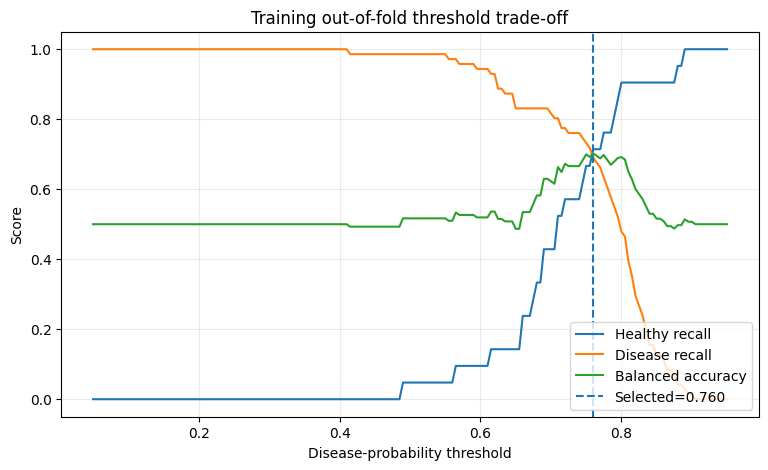

In [ ]:
# Calibration wraps complete leakage-safe pipelines.
# Each calibration fold fits preprocessing and feature selection only on its own training fold.
best_pipeline = final_search.best_estimator_

try:
    calibrated_template = CalibratedClassifierCV(
        estimator=clone(best_pipeline),
        method="sigmoid",
        cv=3,
        n_jobs=N_JOBS,
    )
except TypeError:
    # Compatibility with older sklearn versions.
    calibrated_template = CalibratedClassifierCV(
        base_estimator=clone(best_pipeline),
        method="sigmoid",
        cv=3,
    )

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 200,
)

train_oof_prob = cross_val_predict(
    calibrated_template,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1,  # avoids nested-process instability
)[:, 1]

def threshold_table(y_true, probability):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        pred = (probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

        healthy_recall = tn / (tn + fp) if (tn + fp) else np.nan
        disease_recall = tp / (tp + fn) if (tp + fn) else np.nan
        ba = (healthy_recall + disease_recall) / 2

        rows.append({
            "threshold": threshold,
            "healthy_recall": healthy_recall,
            "disease_recall": disease_recall,
            "minimum_class_recall": min(healthy_recall, disease_recall),
            "balanced_accuracy": ba,
            "accuracy": accuracy_score(y_true, pred),
            "healthy_f1": f1_score(y_true, pred, pos_label=0, zero_division=0),
            "disease_f1": f1_score(y_true, pred, pos_label=1, zero_division=0),
        })
    return pd.DataFrame(rows)

thresholds = threshold_table(y_train.to_numpy(), train_oof_prob)
eligible = thresholds[
    (thresholds["healthy_recall"] >= MIN_HEALTHY_RECALL) &
    (thresholds["disease_recall"] >= MIN_DISEASE_RECALL)
].copy()

candidate_pool = eligible if len(eligible) else thresholds.copy()
candidate_pool["distance_from_half"] = (candidate_pool["threshold"] - 0.5).abs()

best_threshold_row = candidate_pool.sort_values(
    ["minimum_class_recall", "balanced_accuracy", "distance_from_half"],
    ascending=[False, False, True],
).iloc[0]

BEST_THRESHOLD = float(best_threshold_row["threshold"])
print("Selected OOF threshold:", round(BEST_THRESHOLD, 3))
display(best_threshold_row.to_frame("value").round(4))

plt.figure(figsize=(9, 5))
plt.plot(thresholds["threshold"], thresholds["healthy_recall"], label="Healthy recall")
plt.plot(thresholds["threshold"], thresholds["disease_recall"], label="Disease recall")
plt.plot(thresholds["threshold"], thresholds["balanced_accuracy"], label="Balanced accuracy")
plt.axvline(BEST_THRESHOLD, linestyle="--", label=f"Selected={BEST_THRESHOLD:.3f}")
plt.xlabel("Disease-probability threshold")
plt.ylabel("Score")
plt.title("Training out-of-fold threshold trade-off")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
# Fit calibrated model on the complete training set.
try:
    final_calibrated_model = CalibratedClassifierCV(
        estimator=clone(best_pipeline),
        method="sigmoid",
        cv=3,
        n_jobs=N_JOBS,
    )
except TypeError:
    final_calibrated_model = CalibratedClassifierCV(
        base_estimator=clone(best_pipeline),
        method="sigmoid",
        cv=3,
    )

final_calibrated_model.fit(X_train, y_train)

test_probability = final_calibrated_model.predict_proba(X_test)[:, 1]
test_prediction_tuned = (test_probability >= BEST_THRESHOLD).astype(int)
test_prediction_default = (test_probability >= 0.5).astype(int)

def metric_record(y_true, probability, prediction, threshold, rule):
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    healthy_recall = tn / (tn + fp) if (tn + fp) else np.nan
    disease_recall = tp / (tp + fn) if (tp + fn) else np.nan

    return {
        "rule": rule,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "specificity_healthy_recall": healthy_recall,
        "sensitivity_disease_recall": disease_recall,
        "healthy_precision": precision_score(
            y_true, prediction, pos_label=0, zero_division=0
        ),
        "disease_precision": precision_score(
            y_true, prediction, pos_label=1, zero_division=0
        ),
        "healthy_f1": f1_score(
            y_true, prediction, pos_label=0, zero_division=0
        ),
        "disease_f1": f1_score(
            y_true, prediction, pos_label=1, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "mcc": matthews_corrcoef(y_true, prediction),
        "TN_healthy_correct": tn,
        "FP_healthy_as_disease": fp,
        "FN_disease_as_healthy": fn,
        "TP_disease_correct": tp,
    }

comparison = pd.DataFrame([
    metric_record(
        y_test, test_probability, test_prediction_default,
        0.5, "Default threshold"
    ),
    metric_record(
        y_test, test_probability, test_prediction_tuned,
        BEST_THRESHOLD, "OOF class-balanced threshold"
    ),
]).set_index("rule")

display(comparison.round(4))

,threshold,accuracy,balanced_accuracy,specificity_healthy_recall,sensitivity_disease_recall,healthy_precision,disease_precision,healthy_f1,disease_f1,roc_auc,pr_auc,mcc,TN_healthy_correct,FP_healthy_as_disease,FN_disease_as_healthy,TP_disease_correct
rule,,,,,,,,,,,,,,,,
Default threshold,0.50,0.7500,0.5000,0.0000,1.0000,0.0000,0.7500,0.0000,0.8571,0.6944,0.7938,0.0000,0,6,0,18
OOF class-balanced threshold,0.76,0.8333,0.7778,0.6667,0.8889,0.6667,0.8889,0.6667,0.8889,0.6944,0.7938,0.5556,4,2,2,16


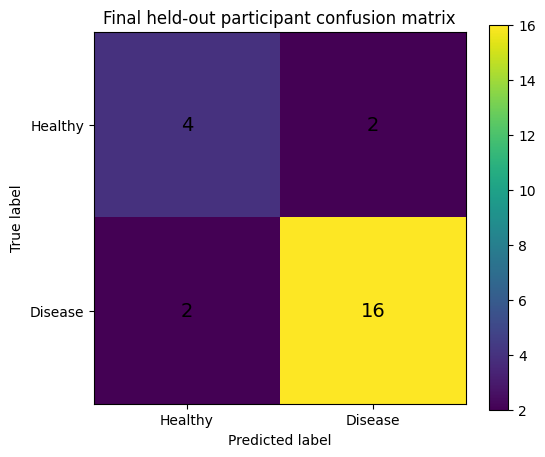

Classification report:
              precision    recall  f1-score   support

     Healthy      0.667     0.667     0.667         6
     Disease      0.889     0.889     0.889        18

    accuracy                          0.833        24
   macro avg      0.778     0.778     0.778        24
weighted avg      0.833     0.833     0.833        24



In [ ]:
# Use the tuned threshold as the final decision rule.
final_prediction = test_prediction_tuned
cm = confusion_matrix(y_test, final_prediction, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1], ["Healthy", "Disease"])
ax.set_yticks([0, 1], ["Healthy", "Disease"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Final held-out participant confusion matrix")
fig.colorbar(im, ax=ax)
plt.show()

print("Classification report:")
print(
    classification_report(
        y_test,
        final_prediction,
        target_names=["Healthy", "Disease"],
        digits=3,
        zero_division=0,
    )
)

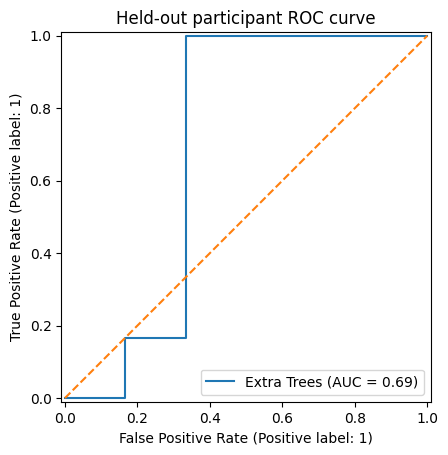

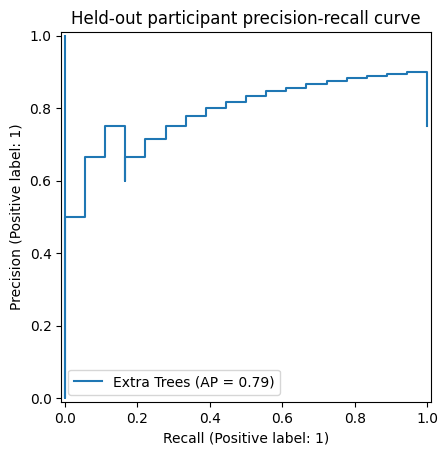

In [ ]:
# ROC and precision-recall curves on the untouched test participants.
RocCurveDisplay.from_predictions(
    y_test, test_probability, name=BEST_MODEL_NAME
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Held-out participant ROC curve")
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_test, test_probability, name=BEST_MODEL_NAME
)
plt.title("Held-out participant precision-recall curve")
plt.show()

In [ ]:
# Participant-level predictions
prediction_table = pd.DataFrame({
    "true_label": y_test,
    "true_text": y_test.map({0: "Healthy", 1: "Disease"}),
    "disease_probability": test_probability,
    "predicted_label": final_prediction,
    "prediction_text": pd.Series(
        final_prediction, index=y_test.index
    ).map({0: "Healthy", 1: "Disease"}),
    "threshold_used": BEST_THRESHOLD,
})
prediction_table["correct"] = (
    prediction_table["true_label"] == prediction_table["predicted_label"]
)
prediction_table.index.name = "Participant ID"

display(prediction_table.sort_values("disease_probability"))

,true_label,true_text,disease_probability,predicted_label,prediction_text,threshold_used,correct
Participant ID,,,,,,,
M2047,0,Healthy,0.610306,0,Healthy,0.76,True
H4045,0,Healthy,0.620137,0,Healthy,0.76,True
H4022,0,Healthy,0.625691,0,Healthy,0.76,True
M2075,0,Healthy,0.638209,0,Healthy,0.76,True
M2025,1,Disease,0.660385,0,Healthy,0.76,False
M2010,1,Disease,0.708986,0,Healthy,0.76,False
C3029,1,Disease,0.762418,1,Disease,0.76,True
H4027,1,Disease,0.773015,1,Disease,0.76,True
P6038,1,Disease,0.776235,1,Disease,0.76,True


In [ ]:
# Bootstrap confidence intervals.
# Stratified bootstrap resamples Healthy and Disease participants separately.
def bootstrap_metrics(
    y_true,
    probability,
    threshold,
    n_boot=2000,
    random_state=42,
):
    y_true = np.asarray(y_true)
    probability = np.asarray(probability)
    rng = np.random.default_rng(random_state)

    idx0 = np.flatnonzero(y_true == 0)
    idx1 = np.flatnonzero(y_true == 1)
    rows = []

    for _ in range(n_boot):
        boot_idx = np.concatenate([
            rng.choice(idx0, size=len(idx0), replace=True),
            rng.choice(idx1, size=len(idx1), replace=True),
        ])
        yb = y_true[boot_idx]
        pb = probability[boot_idx]
        pred = (pb >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(yb, pred, labels=[0, 1]).ravel()

        rows.append({
            "specificity_healthy_recall": tn / (tn + fp),
            "sensitivity_disease_recall": tp / (tp + fn),
            "balanced_accuracy": balanced_accuracy_score(yb, pred),
            "roc_auc": roc_auc_score(yb, pb),
            "pr_auc": average_precision_score(yb, pb),
            "mcc": matthews_corrcoef(yb, pred),
        })

    boot = pd.DataFrame(rows)
    point = metric_record(
        y_true,
        probability,
        (probability >= threshold).astype(int),
        threshold,
        "point",
    )

    wanted = [
        "specificity_healthy_recall",
        "sensitivity_disease_recall",
        "balanced_accuracy",
        "roc_auc",
        "pr_auc",
        "mcc",
    ]

    ci = pd.DataFrame({
        "estimate": [point[m] for m in wanted],
        "ci_2.5%": [boot[m].quantile(0.025) for m in wanted],
        "ci_97.5%": [boot[m].quantile(0.975) for m in wanted],
    }, index=wanted)

    return ci, boot

bootstrap_ci, bootstrap_samples = bootstrap_metrics(
    y_test,
    test_probability,
    BEST_THRESHOLD,
    n_boot=1000 if FAST_MODE else 5000,
    random_state=RANDOM_STATE,
)
display(bootstrap_ci.round(3))

,estimate,ci_2.5%,ci_97.5%
specificity_healthy_recall,0.667,0.333,1.000
sensitivity_disease_recall,0.889,0.722,1.000
balanced_accuracy,0.778,0.556,0.972
roc_auc,0.694,0.343,1.000
pr_auc,0.794,0.661,1.000
mcc,0.556,0.111,0.900


## How to interpret the result

The most important values are:

- **Healthy recall / specificity:** proportion of Healthy participants correctly classified as Healthy.
- **Disease recall / sensitivity:** proportion of diseased participants correctly classified as Disease.
- **Balanced accuracy:** average of the two class recalls.
- **ROC-AUC:** ranking ability across all possible thresholds.
- **MCC:** correlation between predictions and labels; useful for imbalanced classes.
- **Confidence intervals:** uncertainty caused by the limited number of participants.

A model should not be described as clinically diagnostic solely from this dataset. External-cohort validation is required before clinical use.